# 14.5 ANN in PyTorch to Detect Cracks

In this example we will apply our single-layer ANN model to detect cracks in images.  Here we are flattening the images so will lose spatial information, might consider a convolution kernel to preserve spatial relationships.  

The data are sourced from:

[Adrien Müller, Nikos Karathanasopoulos, Christian C. Roth, Dirk Mohr, Machine Learning Classifiers for Surface Crack Detection in Fracture Experiments, International Journal of Mechanical Sciences, Volume 209, (2021), 106698, ISSN 0020-7403](http://54.243.252.9/ce-5319-webroot/3-Readings/1-s2.0-S002074032100429X-main.pdf)

Workflow:
1. **Destroy existing data (need explained below)**
2. Obtain the original dataset (.zip)
3. Use python libraries to extract the images; they are stored in MatLab.mat file structures.
4. Store imgaes locally into subdirectories for processing
5. Then apply our ANN (homebrew or PyTorch)

In [1]:
%reset -f

:::{note}
In this example, we delete the processed data primarily due to GitHub file size limitations and to demonstrate a clean, reproducible workflow.

In real-world research or applications, you typically do not delete large datasets once downloaded and processed. Instead, you would:

- Archive them to a reliable location

- Use versioning and metadata to track provenance

- Avoid redundant downloads to conserve bandwidth and storage

This cleanup is used here for pedagogical clarity and control, especially in constrained teaching environments.
:::

## Data Cleanup Block

:::{warning}
The code block below will permanently delete all downloaded and generated data, including:

- Extracted .mat files and working directories

- Converted .png image files

- CSV files containing image labels

Only run this cell if:

    You want to start fresh

    You have already backed up your work (if needed)

    You're confident all required artifacts can be re-downloaded and regenerated

This is a reasonable practice to demonstrate reproducibility and manage disk space — but treat it with care!
:::

In [2]:
import shutil
import os

# Define directories to delete
dirs_to_remove = [
    "extracted_dataset",  # Contains mmc1 and .mat files
    "images",             # Contains all converted PNGs
    "labels"              # CSV files mapping filenames to labels
]

for target_dir in dirs_to_remove:
    if os.path.exists(target_dir):
        print(f"Deleting: {target_dir}")
        shutil.rmtree(target_dir)
    else:
        print(f"Directory not found (already deleted?): {target_dir}")

print("Cleanup complete.")


Deleting: extracted_dataset
Deleting: images
Deleting: labels
Cleanup complete.


In [3]:
import os
import zipfile
import requests
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

url = "https://ars.els-cdn.com/content/image/1-s2.0-S002074032100429X-mmc1.zip"

# Step 1: Download the ZIP archive
def download_file(url, output_path):
    if not os.path.exists(output_path):
        print(f"Downloading {url}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(output_path, "wb") as f:
            f.write(response.content)
        print(f"Saved to {output_path}")
    else:
        print(f"File already exists: {output_path}")


In [4]:
# Workflow paths
url = "https://ars.els-cdn.com/content/image/1-s2.0-S002074032100429X-mmc1.zip"
zip_file = "dataset.zip"
extract_dir = "extracted_dataset"
png_output_dir = "images"

In [5]:
# Execute workflow
download_file(url, zip_file)

File already exists: dataset.zip


In [6]:
# Step 2: Extract ZIP archive
def extract_zip(zip_path, extract_to):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted to {extract_to}")

In [7]:
extract_zip(zip_file, extract_dir)

Extracting dataset.zip...


Extracted to extracted_dataset


In [8]:
def convert_mat_to_pngs(mat_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for filename in os.listdir(mat_dir):
        if filename.endswith(".mat"):
            full_path = os.path.join(mat_dir, filename)
            print(f"Processing {filename}...")
            mat_data = loadmat(full_path)

            # Try to guess the structure
            for key in mat_data:
                if not key.startswith("__"):
                    images = mat_data[key]

                    # Check dimensions
                    if images.ndim == 3:
                        for i in range(images.shape[2]):
                            img = images[:, :, i]
                            img = np.squeeze(img)
                            output_filename = f"{os.path.splitext(filename)[0]}_{i:03d}.png"
                            plt.imsave(os.path.join(output_dir, output_filename), img, cmap='gray')
                    elif images.ndim == 4:
                        for i in range(images.shape[3]):
                            img = images[:, :, :, i]
                            output_filename = f"{os.path.splitext(filename)[0]}_{i:03d}.png"
                            plt.imsave(os.path.join(output_dir, output_filename), img)
                    else:
                        print(f"Skipping unexpected shape: {images.shape}")
                    break  # process only first candidate
    print("Done.")


In [9]:
convert_mat_to_pngs(os.path.join(extract_dir, "mmc1"), png_output_dir)

Processing NT_NN.mat...
Skipping unexpected shape: (1, 1)
Processing UT_NN.mat...
Skipping unexpected shape: (1, 1)
Processing NT_TestSet_Features.mat...
Skipping unexpected shape: (8, 1407)
Processing ASB_NN.mat...
Skipping unexpected shape: (1, 1)
Processing ASB_TestSet_Features.mat...
Skipping unexpected shape: (21, 3741)
Processing ASB_TestSet_Imgs.mat...


Processing NT_TestSet_Imgs.mat...


Processing UT_TestSet_Imgs.mat...


Processing UT_TestSet_Features.mat...
Skipping unexpected shape: (6, 881)
Done.


This block moves files into subdirectories

In [10]:
import os
import shutil

# Base source directory
source_dir = "./images"

# --- ASB ---
asb_target_dir = os.path.join(source_dir, "ASB")
os.makedirs(asb_target_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    if filename.startswith("ASB_Test"):
        src_path = os.path.join(source_dir, filename)
        dst_path = os.path.join(asb_target_dir, filename)
        if os.path.exists(src_path):  # only move if it still exists
            shutil.move(src_path, dst_path)

# --- NT ---
nt_target_dir = os.path.join(source_dir, "NT")
os.makedirs(nt_target_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    if filename.startswith("NT_Test"):
        src_path = os.path.join(source_dir, filename)
        dst_path = os.path.join(nt_target_dir, filename)
        if os.path.exists(src_path):
            shutil.move(src_path, dst_path)

# --- UT ---
ut_target_dir = os.path.join(source_dir, "UT")
os.makedirs(ut_target_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    if filename.startswith("UT_Test"):
        src_path = os.path.join(source_dir, filename)
        dst_path = os.path.join(ut_target_dir, filename)
        if os.path.exists(src_path):
            shutil.move(src_path, dst_path)

In [11]:
import os
import pandas as pd
from scipy.io import loadmat

# --- ASB ---
prefix = "ASB"
mat_path = f"extracted_dataset/mmc1/{prefix}_TestSet_Features.mat"
output_csv = f"labels/{prefix}_labels.csv"

mat_data = loadmat(mat_path)
labels = mat_data['YTest'].squeeze()

filenames = [f"{prefix}_Image_{i:03d}.png" for i in range(len(labels))]
df = pd.DataFrame({'filename': filenames, 'label': labels.astype(int)})

os.makedirs("labels", exist_ok=True)
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} labels to {output_csv}")

# --- NT ---
prefix = "NT"
mat_path = f"extracted_dataset/mmc1/{prefix}_TestSet_Features.mat"
output_csv = f"labels/{prefix}_labels.csv"

mat_data = loadmat(mat_path)
labels = mat_data['YTest'].squeeze()

filenames = [f"{prefix}_Image_{i:03d}.png" for i in range(len(labels))]
df = pd.DataFrame({'filename': filenames, 'label': labels.astype(int)})

os.makedirs("labels", exist_ok=True)
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} labels to {output_csv}")

# --- UT ---
prefix = "UT"
mat_path = f"extracted_dataset/mmc1/{prefix}_TestSet_Features.mat"
output_csv = f"labels/{prefix}_labels.csv"

mat_data = loadmat(mat_path)
labels = mat_data['YTest'].squeeze()

filenames = [f"{prefix}_Image_{i:03d}.png" for i in range(len(labels))]
df = pd.DataFrame({'filename': filenames, 'label': labels.astype(int)})

os.makedirs("labels", exist_ok=True)
df.to_csv(output_csv, index=False)
print(f"Saved {len(df)} labels to {output_csv}")

Saved 3741 labels to labels/ASB_labels.csv
Saved 1407 labels to labels/NT_labels.csv
Saved 881 labels to labels/UT_labels.csv


In [12]:
shutil.move("./labels/ASB_labels.csv", "./images/ASB/")
shutil.move("./labels/NT_labels.csv", "./images/NT/")
shutil.move("./labels/UT_labels.csv", "./images/UT/");

## PyTorch ANN (Same dataset(s))

**The file pathnames are unique to my computer** and are shown here so the notebook renders and typesets correctly.

In [13]:
import numpy              # useful numerical routines
import scipy.special      # special functions library
import scipy.misc         # image processing code
#import imageio           # deprecated as typical
import imageio.v2 as imageio
import matplotlib.pyplot  # import plotting routines

## Pre-processing Build training and testing sets
# now we have to flatten each image, put into a csv file, and add the truth table
# myann expects
# truth, image ....
# howmanyimages = 881
import csv
howmanyimages = 440 # a small subset for demonstration
testimage = numpy.array([i for i in range(howmanyimages)])
split = 0.1 # fraction to hold out for testing
numwritten = 0
# training file
outputfile1 = "ut-881-train.csv" #local to this directory
outfile1 = open(outputfile1,'w')  # open the file in the write mode
writer1 = csv.writer(outfile1) # create the csv writer
# testing file
outputfile2 = "ut-881-test.csv" #local to this directory
outfile2 = open(outputfile2,'w')  # open the file in the write mode
writer2 = csv.writer(outfile2) # create the csv writer
# process truth table (absolute pathname)
groundtruth = open("/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/images/UT/UT_labels.csv","r") #open the file in the reader mode
reader = csv.reader(groundtruth)
truthtable=[] # empty list to store class
for row in reader:
        truthtable.append(row[1])

for irow in range(len(truthtable)-1):
    truthtable[irow]=truthtable[irow+1] # shift all entries by 1
    
#print(truthtable[0:4])
#import imageio.v3 as imageio  # use imageio.v3 for mode='F'
#import numpy as np
#import csv

# Assume truthtable, split, howmanyimages, writer1, writer2, outfile1, outfile2 already defined
numwritten = 0
np.random.seed(42)
Ntest = 0
Ntrain = 0

for i in range(howmanyimages):
    # build zero-padded image filename: 000, 001, ...
    image_name = f"/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/images/UT/UT_TestSet_Imgs_{i:03}.png"
    
    # read and flatten image
    img_array = imageio.imread(image_name, mode='F')
    img_data = 255.0 - img_array.flatten()  # ensure it's 1D, matches reshape(16384)

    # add label to the front
    newimage = np.insert(img_data, 0, float(truthtable[i]))

    # randomly assign to training or test set
    if np.random.uniform() <= split:
        writer2.writerow(newimage)
        Ntest += 1
    else:
        writer1.writerow(newimage)
        Ntrain += 1
    
    numwritten += 1

outfile1.close()
outfile2.close()
print("Total images segregated and processed:", numwritten)
print("Training images segregated and processed:", Ntrain)
print("Testing images segregated and processed:", Ntest)
print("Lost images :",numwritten - Ntrain - Ntest)

Total images segregated and processed: 440
Training images segregated and processed: 384
Testing images segregated and processed: 56
Lost images : 0


Starting training...


Epoch 1/25, Avg Loss: 0.6996


Epoch 2/25, Avg Loss: 0.6931


Epoch 3/25, Avg Loss: 0.6930


Epoch 4/25, Avg Loss: 0.6930


...

Epoch 21/25, Avg Loss: 0.6400


Epoch 22/25, Avg Loss: 0.6741


Epoch 23/25, Avg Loss: 0.6142


Epoch 24/25, Avg Loss: 0.6425


Epoch 25/25, Avg Loss: 0.6311
Training complete.



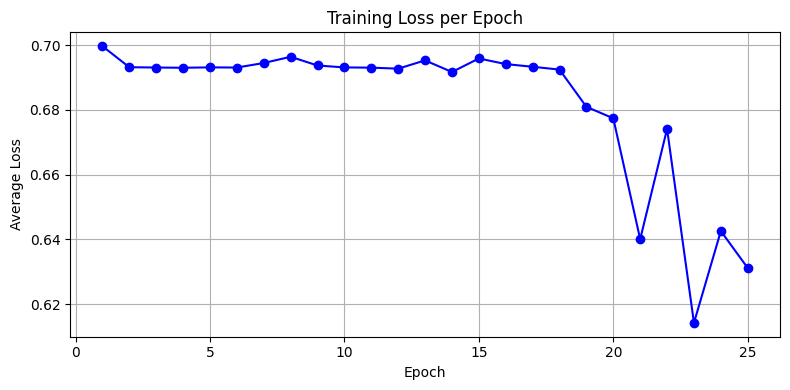

Running test set predictions...


Performance = 0.6071


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# Hyperparameters
INPUT_SIZE = 128 * 128
HIDDEN_SIZE = INPUT_SIZE // 10
OUTPUT_SIZE = 2
LEARNING_RATE = 0.2
EPOCHS = 25
BATCH_SIZE = 8

# Define the ANN model
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(INPUT_SIZE, HIDDEN_SIZE)
        self.fc2 = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Custom Dataset
class UTDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path, header=None)
        self.X = df.iloc[:, 1:].values.astype(np.float32)
        self.y = df.iloc[:, 0].values.astype(np.int64)
        # Normalize like before
        self.X = (self.X / 255.0 * 0.99) + 0.01

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), self.y[idx]

# Load datasets
train_dataset = UTDataset("ut-881-train.csv")
test_dataset  = UTDataset("ut-881-test.csv")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1)

# Initialize model, loss, optimizer
model = SimpleANN()
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#model = SimpleANN()
#criterion = nn.MSELoss()  # similar to original
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# Training loop
#print("Starting training...")
#for epoch in range(EPOCHS):
#    model.train()
#    for batch_X, batch_y in train_loader:
#        outputs = model(batch_X)
#        loss = criterion(outputs, batch_y)

#        optimizer.zero_grad()
#        loss.backward()
#        optimizer.step()
#    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")
#print("Training complete.\n")
loss_history = []  # store average loss per epoch
##### TRAINING LOOP #####
print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)  # accumulate batch loss

    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}")
print("Training complete.\n")
#########################

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), loss_history, marker='o', linestyle='-', color='blue')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluation loop
model.eval()
correct = 0
total = 0

verbose = False
print("Running test set predictions...")
with torch.no_grad():
    for X_test, y_test in test_loader:
        output = model(X_test)
        _, predicted = torch.max(output.data, 1)
        if verbose:
            print(f"predict = {predicted.item()}  true = {y_test.item()}  = {'correct' if predicted == y_test else 'wrong'}")
        total += 1
        correct += (predicted == y_test).sum().item()

accuracy = correct / total
print(f"Performance = {accuracy:.4f}")


### Interpretation of Loss Curve
- Steady decline → healthy learning
- Early plateau → learning rate too low
- Noisy or rising → learning rate too high or data inconsistency



In [15]:
import imageio.v2 as imageio  # PyTorch prefers Pillow, but this keeps your original structure
import matplotlib.pyplot as plt
import numpy as np
import torch

def classify_and_display_image_pytorch(model, image_path):
    """Classify a new image using the trained PyTorch model and display it."""
    # Load grayscale image
    img_array = imageio.imread(image_path, mode='F')  # float32 output
    img_array = np.max(img_array) - img_array         # Invert colors (as done in MNIST)
    
    # Normalize and reshape
    img_data = (img_array / 255.0 * 0.99) + 0.01
    input_tensor = torch.tensor(img_data.flatten(), dtype=torch.float32).unsqueeze(0)  # shape: [1, 784]
    
    # Disable gradient tracking for inference
    with torch.no_grad():
        output = model(input_tensor)
        label = torch.argmax(output).item()

    # Plot image and prediction
    plt.imshow(img_array, cmap='Greys')
    plt.title(f"Predicted Label: {label}")
    plt.axis('off')
    plt.show()
    
    return label

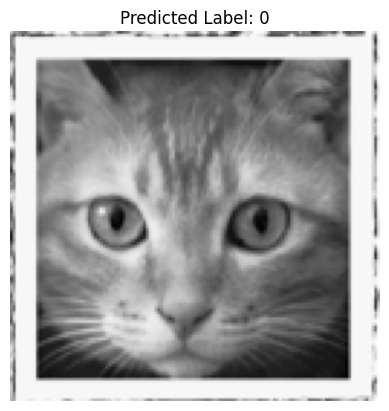

0

In [16]:
classify_and_display_image_pytorch(model, "/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/cat128.png")

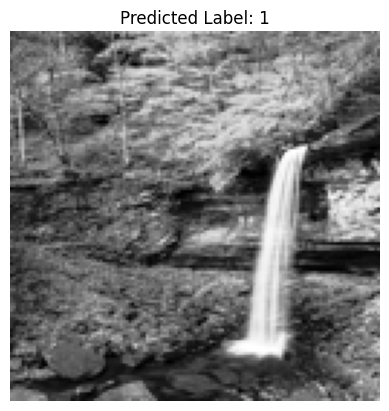

1

In [17]:
classify_and_display_image_pytorch(model, "/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/waterfall128.png")

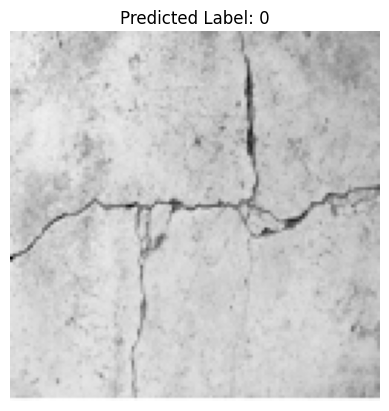

0

In [18]:
classify_and_display_image_pytorch(model, "/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/concrete-cracks.png")

## PyTorch Convolution Neural Network

A Convolutional Neural Network (CNN) approach, is much more natural for spatially structured data like the 128×128 grayscale crack/no-crack images.

### Why Use a CNN Here?
The current MLP (fully connected layers) flattens the image and ignores spatial structure.

A CNN with a 9-pixel mask (i.e., a 3×3 convolution kernel; other kernels can be used) learns spatial patterns, such as edges and textures — precisely what you’d want for detecting cracks. The 3×3 convolution filter, slides across the image with padding to preserve dimensions. In CNNs, the filter weights are learned, not fixed - so that is a huge advantage to having to specify interpolative functions (as is done in other image processing contexts).

Illustrative code (in PyTorch) is simply replacing a few parts in the code above.

Starting training...


Epoch 1/25, Avg Loss: 0.7084


Epoch 2/25, Avg Loss: 0.6889


Epoch 3/25, Avg Loss: 0.6954


Epoch 4/25, Avg Loss: 0.6899


...

Epoch 21/25, Avg Loss: 0.6957


Epoch 22/25, Avg Loss: 0.6946


Epoch 23/25, Avg Loss: 0.6957


Epoch 24/25, Avg Loss: 0.6951


Epoch 25/25, Avg Loss: 0.6959
Training complete.



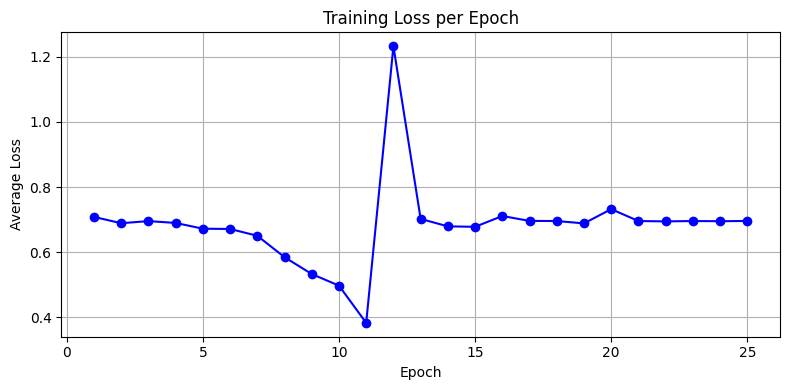

Running test set predictions...


Performance = 0.5000


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# Hyperparameters
INPUT_SIZE = 128 * 128
HIDDEN_SIZE = INPUT_SIZE // 10
OUTPUT_SIZE = 2
LEARNING_RATE = 0.09
EPOCHS = 25
BATCH_SIZE = 8

# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)  # 3×3 mask
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Downsamples 128×128 → 64×64
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)  # Second convolution
        self.fc1 = nn.Linear(16 * 32 * 32, 64)  # Flattened after second pooling
        self.fc2 = nn.Linear(64, 2)  # Final classification (2 classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # [batch, 8, 64, 64]
        x = self.pool(torch.relu(self.conv2(x)))  # [batch, 16, 32, 32]
        x = x.view(-1, 16 * 32 * 32)              # Flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Custom Dataset
class UTDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path, header=None)
        self.X = df.iloc[:, 1:].values.astype(np.float32)
        self.y = df.iloc[:, 0].values.astype(np.int64)
        # Normalize like before
        self.X = (self.X / 255.0 * 0.99) + 0.01

    def __len__(self):
        return len(self.y)

    #def __getitem__(self, idx):
    #    return torch.from_numpy(self.X[idx]), self.y[idx]

    def __getitem__(self, idx):
        x = self.X[idx].reshape(1, 128, 128)  # Add channel dimension
        return torch.from_numpy(x), self.y[idx]

# Load datasets
train_dataset = UTDataset("ut-881-train.csv")
test_dataset  = UTDataset("ut-881-test.csv")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1)

# Initialize model, loss, optimizer
#model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
model = SimpleCNN()
#criterion = nn.MSELoss()  # similar to original
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# Training loop
#print("Starting training...")
#for epoch in range(EPOCHS):
#    model.train()
#    for batch_X, batch_y in train_loader:
#        outputs = model(batch_X)
#        loss = criterion(outputs, batch_y)

#        optimizer.zero_grad()
#        loss.backward()
#        optimizer.step()
#    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")
#print("Training complete.\n")
loss_history = []  # store average loss per epoch
##### TRAINING LOOP #####
print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)  # accumulate batch loss

    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}")
print("Training complete.\n")
#########################

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), loss_history, marker='o', linestyle='-', color='blue')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluation loop
model.eval()
correct = 0
total = 0

verbose = False
print("Running test set predictions...")
with torch.no_grad():
    for X_test, y_test in test_loader:
        output = model(X_test)
        _, predicted = torch.max(output.data, 1)
        if verbose:
            print(f"predict = {predicted.item()}  true = {y_test.item()}  = {'correct' if predicted == y_test else 'wrong'}")
        total += 1
        correct += (predicted == y_test).sum().item()

accuracy = correct / total
print(f"Performance = {accuracy:.4f}")

In [20]:
def predict_image(img_path, model):
    import imageio.v3 as imageio
    img_array = imageio.imread(img_path, mode='F')
    img_array = np.max(img_array) - img_array         # Invert colors 
    img_data = 255.0 - img_array.flatten()
    img_data = ((img_data / 255.0) * 0.99) + 0.01
    img_tensor = torch.from_numpy(img_data.astype(np.float32).reshape(1, 1, 128, 128))  # shape: [1,1,128,128]
    model.eval()
    with torch.no_grad():
        out = model(img_tensor)
        label = torch.argmax(out).item()

    # Plot image and prediction
    plt.imshow(img_array, cmap='Greys')
    plt.title(f"Predicted Label: {label}")
    plt.axis('off')
    plt.show()
    return label

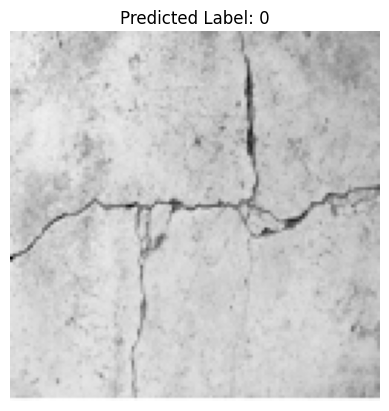

0

In [21]:
predict_image("/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/concrete-cracks.png" ,model)

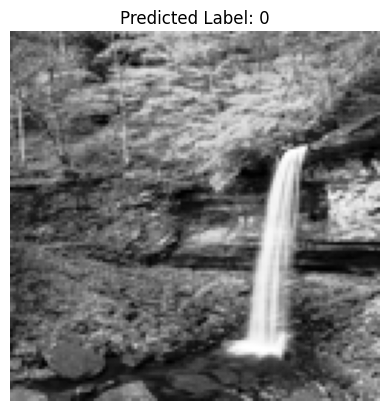

0

In [22]:
predict_image("/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/waterfall128.png" ,model)

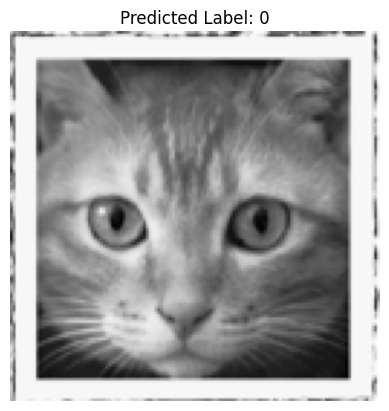

0

In [23]:
predict_image("/home/sensei/ce-5319-webroot/MLBE4CE/chapters/14-neuralnetworks/cat128.png" ,model)